In [36]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from scipy.spatial.distance import cdist
from scipy import stats
from pathlib import Path
import warnings
import traceback
import sys

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### CASE STUDY SELECTION AND CONFIGURATION

In [53]:
CURRENT_CASE = 'VALENCIA'  #'VALENCIA' o 'ER' (for the Emilia-Romagna case)

#GENERAL PARAMETERS
ESEGUI_PRECALCOLO = False   #True if it needs to calculate again the Euclidean distances   
ESEGUI_ANALISI_PLOT = True     
ESEGUI_ANALISI_PROXY = False  #True if you want all the proxy maps (it might be necessary to adjust the colors for this one)
SALVA_FIGURE = False           
NUM_ANALOGS = 30
QUANTILE = 0.98
N_BOOTSTRAP_RUNS = 100
RUN_BOOTSTRAP = True
N_COLOR_LEVELS = 12

config = {}

if CURRENT_CASE == 'ER':
    # EMILIA ROMAGNA
    config['PATHS'] = {
        'INPUT': 'D:/TESI/Codice_tesi/ERfloods/for_ERfloods/',
        'OUTPUT': 'D:/TESI/OUTPUT/'
    }

    config['FILE_SUFFIX'] = '_AMJ_2Maggio_finale'
    
    config['DATES'] = {
        'START': 1951, 'END': 2023, 
        'EVENT_YEAR': 2023, 'EVENT_DAY': "05-02",   #Change the event's day here
        'SEASON_MONTHS': [4, 5, 6], 
        'SEARCH_END': 2021
    }
    
    if config['DATES']['EVENT_DAY'] == "05-02":
        config['BLACKLIST'] = ['2023-05-16', '2023-05-17', '2023-05-18']     #Days too close to the event
    elif config['DATES']['EVENT_DAY'] in ["05-16", "05-17"]:
        config['BLACKLIST'] = ['2023-05-01', '2023-05-02', '2023-05-03']
    else:
        config['BLACKLIST'] = []

    config['PROXY_VARS'] = ['precipitation', 'runoff', 'vorticity', 'msl']
    config['MULTI_VARS'] = ['runoff', 'msl', 'precipitation']
    
    config['VARIABLES'] = [
        {'id': 'runoff', 'file': 'ERA5_srunoff_1940-2023_amj_europe_dm.nc', 'var_name': 'var8', 
         'slice_type': 'isel', 'lon': slice(111, 132), 'lat': slice(62, 79), 'scale': 1},
        {'id': 'vorticity', 'file': 'era5_vorticity_daily_eu_500_amj.nc', 'var_name': 'vo', 
         'slice_type': 'isel', 'lon': slice(140, 209), 'lat': slice(108, 157), 'scale': 1},
        {'id': 'msl', 'file': 'ERA5_msl_day_r720x360_sfc_1951-2023_amj_europe.nc', 'var_name': 'msl', 
         'slice_type': 'isel', 'lon': slice(40, 111), 'lat': slice(0, 41), 'scale': 1},
        {'id': 'precipitation', 'file': 'ARCIS3_GG_1961-2023_amj.nc', 'var_name': 'rr', 
         'slice_type': 'isel', 'lon': slice(55, 123), 'lat': slice(25, 116), 'scale': 1}
    ]

elif CURRENT_CASE == 'VALENCIA':
    # VALENCIA 
    config['PATHS'] = {
        'INPUT': r'D:\Articolo_VAL\ALTRI_DATI_VAL',  #your file's path
        'OUTPUT': r'D:\Articolo_VAL\ALTRI_DATI_VAL\OUTPUT_VALENCIA_FINALE'
    }
    config['FILE_SUFFIX'] = '_paper_VAL_end'   #Change here if you don't want to overwrite the file of the distance values 
    
    config['DATES'] = {
        'START': 1950, 'END': 2024,
        'EVENT_YEAR': 2024, 'EVENT_DAY': "10-29",
        'SEASON_MONTHS': [9, 10, 11],   #SON 
        'SEARCH_END': 2023
    }
    config['BLACKLIST'] = ['2024-10-28', '2024-10-29', '2024-10-30']

    
    config['PROXY_VARS'] = ['precipitation', 'runoff', 'gh700', 'vort_shear', 'wind_shear']
    config['MULTI_VARS'] = ['precipitation', 'gh700', 'runoff']    ##Change here for the multivariate combination

config['VARIABLES'] = [
        # local varibles (precipitation and runoff)
        {'id': 'runoff', 'file': 'runoff_MERGED_natalia3.nc', 'var_name': 'ro_daily_sum', #your variables' names and files
         'slice_type': 'sel', 'lon': (-3, 3), 'lat': (35, 41), 'scale': 1},
         
        {'id': 'precipitation', 'file': 'era5_prec_son_merged_UNIFORM.nc', 'var_name': 'tp_daily_sum',
         'slice_type': 'sel', 'lon': (-3, 3), 'lat': (35, 41), 'scale': 1000}, #1000 for mm
         
        # new varibles
        {'id': 'gh700', 'file': 'z700_1950_2024_SON_end.nc', 'var_name': 'gh700',  ##your variables' names and files
         'slice_type': 'sel', 'lon': (-10, 5), 'lat': (35, 45), 'scale': 1},
         
        {'id': 'vort_shear', 'file': 'vort_shear_1950_2024_SON_end.nc', 'var_name': 'vort_shear', ##your variables' names and files
         'slice_type': 'sel', 'lon': (-10, 5), 'lat': (35, 45), 'scale': 1},
         
        {'id': 'wind_shear', 'file': 'wind_shear_1950_2024_SON_end.nc', 'var_name': 'wind_shear', ##your variables' names and files
         'slice_type': 'sel', 'lon': (-10, 5), 'lat': (35, 45), 'scale': 1}
]

### STATISTICAL FUNCTIONS

In [55]:
def calculate_signt(years_of_analogs, total_years_range, n_intervals=14):
    try:
        year_bins = np.linspace(total_years_range[0], total_years_range[-1], n_intervals + 1)
        counts, _ = np.histogram(years_of_analogs, bins=year_bins)
        
        x = np.arange(1, n_intervals + 1)
        
        slope, _, _, _, std_err = stats.linregress(x, counts)
        
        alpha = 0.10 #confidence level at 90%
        t_val = stats.t.ppf(1 - alpha/2, len(x)-2)
        
        ci_lower = slope - (t_val * std_err)
        ci_upper = slope + (t_val * std_err)
        
        return np.sign(ci_lower) + np.sign(ci_upper)
    except Exception:
        return 0.0

#################################################################################################################

def bootstrap_significance(dates_cold, dates_warm, indices_cold, indices_warm, 
                           data_cold, data_warm, anom_real, n_bootstrap=100):
    data_all = xr.concat([data_cold, data_warm], dim='time')
    data_all_np = data_all.values
    n_total = len(data_all.time)
    
    n_cold = len(indices_cold)
    n_warm = len(indices_warm)
    
    anom_btstr_list = []
    
    for _ in range(n_bootstrap):
        idx1 = np.random.choice(n_total, size=n_cold, replace=False)
        idx2 = np.random.choice(n_total, size=n_warm, replace=False)
        
        m1 = np.nanmean(data_all_np[idx1], axis=0)
        m2 = np.nanmean(data_all_np[idx2], axis=0)
        anom_btstr_list.append(m2 - m1)
    
    anom_btstr_stack = np.stack(anom_btstr_list, axis=0)
    std_anom_btstr = 2 * np.nanstd(anom_btstr_stack, axis=0) #2sigma
    
    return np.abs(anom_real.values) > std_anom_btstr

#################################################################################################################

def print_analog_dates(analogs, label):
    print(f"\n{'='*25} TOP {NUM_ANALOGS} ANALOGHI: {label} {'='*25}")
    cold_dates = analogs['cold']['data'].time.values
    warm_dates = analogs['warm']['data'].time.values
    print(f"{'Rank':<5} | {'COUNTERFACTUAL PERIOD':<20} | {'FACTUAL PERIOD':<20}")
    print("-" * 55)
    for i in range(NUM_ANALOGS):
        d_cold = str(cold_dates[i])[:10] if i < len(cold_dates) else "---"
        d_warm = str(warm_dates[i])[:10] if i < len(warm_dates) else "---"
        print(f"{i+1:<5} | {d_cold:<20} | {d_warm:<20}")
    print("=" * 60)

### PLOTTING FUNCTIONS

In [58]:
def analyze_by_trend_sign(da, dists, signt, var_id, output_dir, num_analogs=30):
    print(f"   -> [TREND analysis] Map Generation by Trend Sign...")
    
    groups = {
        'Positive': np.where(signt > 0)[0],
        'Neutral':  np.where(signt == 0)[0],
        'Negative': np.where(signt < 0)[0]
    }
    
    print(f"      Counts -> Pos: {len(groups['Positive'])}, Neu: {len(groups['Neutral'])}, Neg: {len(groups['Negative'])}")
    
    composites = {}
    for label, indices in groups.items():
        if len(indices) < 5: 
            composites[label] = None
            continue
            
        group_dists = dists[indices]
        sorted_local_idx = np.argsort(group_dists)
        limit = min(num_analogs, len(sorted_local_idx))
        top_local_idx = sorted_local_idx[:limit]
        best_global_indices = indices[top_local_idx]
        
        comp_mean = da.isel(time=best_global_indices).mean('time')
        composites[label] = comp_mean

    if all(v is None for v in composites.values()):
        print("   Nessun gruppo valido per il plot trend.")
        return

    var_conf = next((item for item in config['VARIABLES'] if item["id"] == var_id), {'scale': 1})
    scale_f = var_conf['scale']
    
# UNITS
    unit_label = ""
    use_sci = False
    
    if 'runoff' in var_id:
        unit_label = "m"
        use_sci = True
    elif 'vorticity' in var_id or 'vort_shear' in var_id:
        unit_label = "s$^{-1}$"
        use_sci = True
    elif 'precipitation' in var_id:
        unit_label = "mm"
    elif 'msl' in var_id:
        unit_label = "Pa"
    elif 'gh700' in var_id or 'z700' in var_id:
        unit_label = "m"
        use_sci = False
    elif 'wind_shear' in var_id:
        unit_label = "m/s"
        use_sci = False

    # scientific notation and colorbar
    sci_formatter = ScalarFormatter(useMathText=True)
    sci_formatter.set_powerlimits((-1, 1))
    
    valid_vals = [c.values * scale_f for c in composites.values() if c is not None]
    if not valid_vals: return
    all_vals_flat = np.concatenate([v.flatten() for v in valid_vals])
    abs_max = np.nanmax(np.abs(all_vals_flat))
    if abs_max == 0: abs_max = 1
    
    levels = np.linspace(-abs_max, abs_max, 21) 
    #levels=11
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    titles = ['Positive Trend  (>0)', 'Neutral Trend  (0)', 'Negative Trend (<0)']
    keys = ['Positive', 'Neutral', 'Negative']
    
    for i, ax in enumerate(axes):
        key = keys[i]
        data = composites[key]
        
        if data is None:
            ax.text(0.5, 0.5, f"Insufficient data (<5)", ha='center', transform=ax.transAxes)
            continue
        
        lat = data.latitude.values if 'latitude' in data.coords else data.lat.values
        lon = data.longitude.values if 'longitude' in data.coords else data.lon.values
        
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6)
        
        # Gridlines (Lat/Lon)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = True
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 9}
        gl.ylabel_style = {'size': 9}
        
        #limiti plot
        ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
        
        plot_data = data * scale_f

        cf = ax.contourf(lon, lat, plot_data, levels=levels, cmap='RdBu', extend='both', transform=ccrs.PlateCarree())
        cb = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, fraction=0.05)
        
        if use_sci:
             cb.ax.xaxis.set_major_formatter(sci_formatter)
             
        cb.set_label(f"[{unit_label}]", fontsize=11, weight='bold')
        ax.set_title(f"{titles[i]} (N={len(groups[key])})")
    
    clean_id = var_id.capitalize()
    plt.suptitle(f"Analisi per Segno: {clean_id} ({CURRENT_CASE})", fontsize=16, y=0.95)
    
    if SALVA_FIGURE:
        out_path = Path(output_dir) / f"TrendSign_{var_id}.png"
        plt.savefig(out_path, bbox_inches='tight', dpi=300)
        plt.close()
    else:
        plt.show()

#################################################################################################################

def analyze_runoff_magnitudes_valencia(analogs_dict, full_da, target_date_str, output_dir):
    print(f"\n****** [VALENCIA] RUNOFF plot ******")
    try:
        target_val = full_da.sel(time=target_date_str).mean(['lat', 'lon']).item()
    except: return
    periods_data = {'cold': [], 'warm': []}
    plt.figure(figsize=(10, 6))
    for period, color in zip(['cold', 'warm'], ['blue', 'red']):
        da_sub = analogs_dict[period]['data']
        vals = da_sub.mean(['lat', 'lon']).values
        periods_data[period] = vals
        plt.plot(np.arange(1, len(vals)+1), vals, 'o-', color=color, alpha=0.7, label=f'{period.capitalize()}')
    plt.axhline(y=target_val, color='black', linestyle='--', label='Target Event')
    plt.title('Runoff intensity comparison')
    plt.legend()
    if SALVA_FIGURE: plt.savefig(Path(output_dir) / "runoff_magnitude.png"); plt.close()
    else: plt.show()

#################################################################################################################

def plot_distance_histogram(dists_dict, output_dir, filename="histogram.png", title=None):
    plt.figure(figsize=(10, 5))
    colors = colors = {
        'runoff': '#d95319', 
        'vorticity': '#0072bd', 
        'precipitation': '#77ac30', 
        'msl': '#7e2f8e',
        'gh700': '#a2142f',
        'vort_shear': '#edb120',
        'wind_shear': '#4dbeee' 
    }
    bins = np.linspace(0, 1, 61)
    
    plotted = False
    for vid, dists in dists_dict.items():
        valid = dists[~np.isnan(dists)]
        if len(valid) == 0: continue
        plt.hist(valid, bins=bins, weights=np.ones_like(valid)/len(valid), alpha=0.6,
                 label=vid.capitalize(), color=colors.get(vid, 'gray'), edgecolor='k', linewidth=0.3)
        plotted = True
        
    if plotted:
        plt.xlabel('Euclidean distance'); plt.ylabel('Norm. Freq.')
        plt.title(title if title else "Distribution of Analog Distances")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.xlim(0, 1); plt.ylim(0, 0.5)
        if SALVA_FIGURE:
            (Path(output_dir)/"FIG").mkdir(parents=True, exist_ok=True)
            plt.savefig(Path(output_dir)/"FIG"/filename, dpi=300, bbox_inches='tight'); plt.close()
        else: plt.show()

#################################################################################################################

def plot_composite_maps(analogs_dict, var_id, output_path, significance_mask=None):
    base_id = var_id
    if "_multivariate" in var_id: base_id = var_id.replace("_multivariate", "")
    elif "_proxy_" in var_id: base_id = var_id.split("_proxy_")[0]
    
    var_conf = next((item for item in config['VARIABLES'] if item["id"] == base_id), {'scale': 1})
    scale = var_conf['scale']
    
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((-2, 2))
    
# UNITS
    unit_label = ""
    use_sci = False
    cmap_choice = 'RdBu'
    
    if 'runoff' in var_id:
        unit_label = "m"
        use_sci = True
    elif 'vorticity' in var_id or 'vort_shear' in var_id:
        unit_label = "s$^{-1}$"
        use_sci = True
    elif 'precipitation' in var_id:
        unit_label = "mm"
    elif 'msl' in var_id:
        unit_label = "Pa"
    elif 'gh700' in var_id or 'z700' in var_id:
        unit_label = "m"
        use_sci = False
        cmap_choice = 'RdBu_r'
    elif 'wind_shear' in var_id:
        unit_label = "m/s"
        use_sci = False

    cold_da = analogs_dict['cold']['data'].mean('time') * scale
    warm_da = analogs_dict['warm']['data'].mean('time') * scale
    lat_n = 'lat' if 'lat' in cold_da.coords else 'latitude'


    if significance_mask is not None:
        if not isinstance(significance_mask, xr.DataArray):
            significance_mask = xr.DataArray(significance_mask, coords=cold_da.coords, dims=cold_da.dims)
        significance_mask = significance_mask.sortby(lat_n)

    # Ordering the data
    cold_da = cold_da.sortby(lat_n)
    warm_da = warm_da.sortby(lat_n)
    diff_da = warm_da - cold_da
    

    # better colors for gh700
    color_scale_factor = 1.25 if ('gh700' in base_id or 'z700' in base_id) else 1.0
    
    abs_max = max(abs(cold_da.min().item()), abs(cold_da.max().item()), abs(warm_da.min().item()), abs(warm_da.max().item())) * color_scale_factor
    abs_diff = abs(diff_da).max().item() * color_scale_factor
    
    
    levels_c = np.linspace(-abs_max, abs_max, N_COLOR_LEVELS)
    levels_d = np.linspace(-abs_diff, abs_diff, N_COLOR_LEVELS)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    data_list = [(cold_da, "Counterfactual Period", levels_c), (warm_da, "Factual period", levels_c), (diff_da, "Difference", levels_d)]
    
    for i, (data, title, levs) in enumerate(data_list):
        ax = axes[i]
        lon = data.longitude.values if 'longitude' in data.coords else data.lon.values
        lat = data[lat_n].values
        
        if i == 2 and significance_mask is not None:
            if lon.ndim == 1 and lat.ndim == 1:
                lon_2d, lat_2d = np.meshgrid(lon, lat)
            else:
                lon_2d, lat_2d = lon, lat

        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6)
        
        # Gridlines (Lat/Lon) 
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = True
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 9}
        gl.ylabel_style = {'size': 9}
        
        #limiti
        ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
        
        cf = ax.contourf(lon, lat, data, levels=levs, cmap=cmap_choice, extend='both', transform=ccrs.PlateCarree())
        cb = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, fraction=0.05)
        if use_sci: cb.ax.xaxis.set_major_formatter(fmt)
        cb.set_label(f"[{unit_label}]", fontsize=11, weight='bold')
        ax.set_title(title)



        # PLOT BOOTSTRAP 
        if i == 2 and significance_mask is not None:
            # Using the NOT to cover (stipple) the non-significant areas.
            mask_np = np.logical_not(significance_mask.values)
            

            ax.contourf(lon, lat, mask_np, levels=[0.5, 1.5], 
                        colors='none', hatches=['...'], 
                        transform=ccrs.PlateCarree())


    plt.suptitle(f"Composite Maps: {var_id} ({CURRENT_CASE})", fontsize=16)
    if SALVA_FIGURE: plt.savefig(Path(output_path) / f"comp_{var_id}.png", bbox_inches='tight', dpi=300); plt.close()
    else: plt.show()

### LOADING AND CALCULATION FUNCTIONS

In [61]:
def precompute_variable(var_conf, output_dir):
    var_id = var_conf['id']
    print(f"\n--- Elaboration: {var_id} ---")
    input_path = Path(config['PATHS']['INPUT']) / var_conf['file']
    try:
        ds = xr.open_dataset(input_path, decode_times=True)
        # ... (expver problem and renaming time ) ...
        if 'expver' in ds.dims: ds = ds.sel(expver=1).combine_first(ds.sel(expver=5))
        elif 'expver' in ds.coords: ds = ds.drop_vars('expver')
        if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
        try: ds['time'] = ds.time.dt.floor('D')
        except: pass

        full_data = ds[var_conf['var_name']]
        #gestione slicing spaziale
        lon_n = 'longitude' if 'longitude' in full_data.coords else 'lon'
        lat_n = 'latitude' if 'latitude' in full_data.coords else 'lat'
        
        if var_conf['slice_type'] == 'isel':
            domain_data = full_data.isel({lon_n: var_conf['lon'], lat_n: var_conf['lat']})
        else:
            lat_vals = full_data[lat_n].values
            lat_r = var_conf['lat']
            lat_s = slice(lat_r[0], lat_r[1]) if lat_vals[0] < lat_vals[-1] else slice(lat_r[1], lat_r[0])
            domain_data = full_data.sel({lon_n: slice(var_conf['lon'][0], var_conf['lon'][1]), lat_n: lat_s})

        #Gestione bisestili
        seasonal_data = domain_data.where(domain_data.time.dt.month.isin(config['DATES']['SEASON_MONTHS']), drop=True)
        seasonal_data = seasonal_data.sel(time=~((seasonal_data.time.dt.month == 2) & (seasonal_data.time.dt.day == 29)))
        day_month_str = seasonal_data.time.dt.strftime('%m-%d')
        seasonal_data.coords['day_month'] = day_month_str
        
        #anomalie su base MESE-GIORNO
        climatology = seasonal_data.groupby('day_month').mean('time')
        anomalies = (seasonal_data.groupby('day_month') - climatology).fillna(0.0)
        anomalies = anomalies.drop_vars('day_month')
        
        #Distances
        t_start = np.datetime64(f"{config['DATES']['START']}-01-01")
        t_end = np.datetime64(f"{config['DATES']['END']}-12-31")
        anomalies = anomalies.sel(time=slice(t_start, t_end))
        
        print(f"   Distance calculation on {len(anomalies.time)} step...")
        X = np.nan_to_num(anomalies.values.reshape(len(anomalies.time), -1), nan=0.0)
        dists_matrix = cdist(X, X, metric='euclidean')
        
        log_dists = -np.log(dists_matrix + 1e-9)
        thresholds = np.quantile(log_dists, QUANTILE, axis=1)
        dist_av = np.zeros(len(anomalies.time))
        signt = np.zeros(len(anomalies.time))
        for i in range(len(anomalies.time)):
            mask = log_dists[i, :] > thresholds[i]
            if np.sum(mask) > 0:
                dist_av[i] = np.mean(dists_matrix[i, mask])
                yrs = anomalies.time.dt.year.values[mask]
                signt[i] = calculate_signt(yrs, np.arange(config['DATES']['START'], config['DATES']['END']+1))
        
        outfile = Path(output_dir) / f"precomputed_{var_id}{config['FILE_SUFFIX']}.npz"
        times_int = anomalies.time.dt.strftime('%Y%m%d').astype(int).values
        np.savez_compressed(outfile, dist_av=dist_av, signt=signt, data=anomalies.values.astype(np.float32),
                            T=times_int, lat=domain_data[lat_n].values, lon=domain_data[lon_n].values)
        print(f"   Salvato: {outfile.name}")

    except Exception as e:
        print(f"   ERROR ON {var_id}: {e}")
        traceback.print_exc()

#################################################################################################################

def load_precomputed(var_id, base_path):
    fpath = Path(base_path) / f"precomputed_{var_id}{config['FILE_SUFFIX']}.npz"
    if not fpath.exists(): 
        print(f"File not found: {fpath}")
        return None
    raw = np.load(fpath)
    data = raw['data']
    if data.ndim == 4: data = np.nanmean(data, axis=1)
    
    times_pd = [np.datetime64(f"{str(t)[:4]}-{str(t)[4:6]}-{str(t)[6:8]}") for t in raw['T']]
    da = xr.DataArray(data, coords={'time': times_pd, 'lat': raw['lat'], 'lon': raw['lon']},
                      dims=['time', 'lat', 'lon'], name=var_id)
    
    signt_da = xr.DataArray(raw['signt'], coords={'time': times_pd}, dims='time', name='signt')
    
    return {'da': da, 'dist_av': raw['dist_av'], 'signt_da': signt_da}

#################################################################################################################

def calculate_relative_distances(da, dist_av, target_date_str, blacklist_dates=[]):
    t_clean = str(np.datetime64(target_date_str))[:10]
    bl_clean = [str(np.datetime64(d))[:10] for d in blacklist_dates] + [t_clean]
    time_strs = np.array([str(t)[:10] for t in da.time.values], dtype=object)
    
    try: idx_evt = np.where(time_strs == t_clean)[0][0]
    except: print(f"Warning: Event {t_clean} not found."); return None, None
    
    search_lim = np.datetime64(f"{config['DATES']['SEARCH_END']}-12-31")
    mask_time = (da.time <= search_lim)
    mask_season = da.time.dt.month.isin(config['DATES']['SEASON_MONTHS'])
    mask_bl = ~np.isin(time_strs, bl_clean)
    final_mask = mask_time & mask_season & mask_bl
    
    if CURRENT_CASE == 'ER': 
        final_mask = final_mask & (da.time.dt.year != 1991)

    da_sub = da.isel(time=final_mask)
    dist_sub = dist_av[final_mask]
    
    if len(dist_sub) == 0: return None, None
    dmin, dmax = np.nanmin(dist_sub), np.nanmax(dist_sub)
    if dmin == dmax: return None, None
    d_norm = (dist_sub - dmin) / (dmax - dmin)
    d0_norm = (dist_av[idx_evt] - dmin) / (dmax - dmin)
    return da_sub, np.abs(d_norm - d0_norm)

#################################################################################################################

def select_analogs(da, dists, n_analogs=30):
    mid = len(da.time) // 2
    res = {}
    for key, (d_slice, dist_slice) in {'cold': (da[:mid], dists[:mid]), 'warm': (da[mid:], dists[mid:])}.items():
        sorted_idx = np.argsort(dist_slice)
        sel_idx = []
        i = 0
        while len(sel_idx) < n_analogs and i < len(sorted_idx):
            idx = sorted_idx[i]
            if not any(abs(idx - s) <= 7 for s in sel_idx): sel_idx.append(idx)
            i += 1
        res[key] = {'data': d_slice.isel(time=sel_idx), 'indices': sel_idx}
    return res

# MAIN

>>> STARTING ANALYSIS: VALENCIA <<<

>>> Distance Calculation vs 2024-10-29 (Blacklist: ['2024-10-28', '2024-10-29', '2024-10-30'])

>>> HISTOGRAM GENERATION <<<


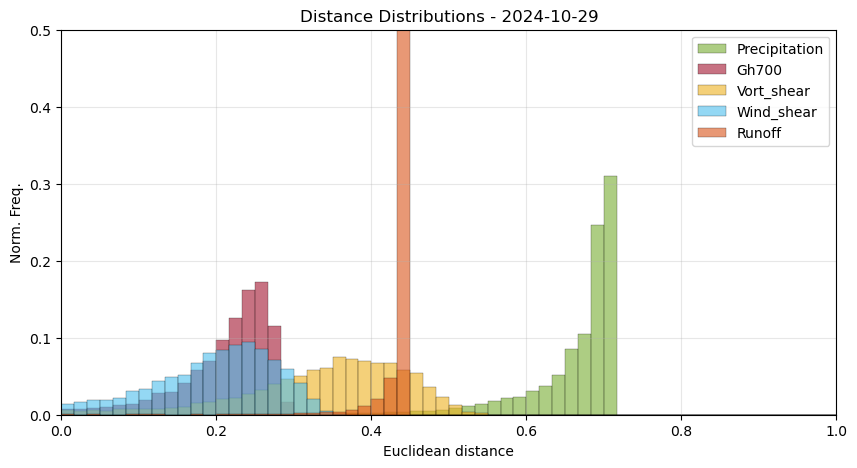

   Runoff 'Wet' Days (> 1e-05): 778 su 6734


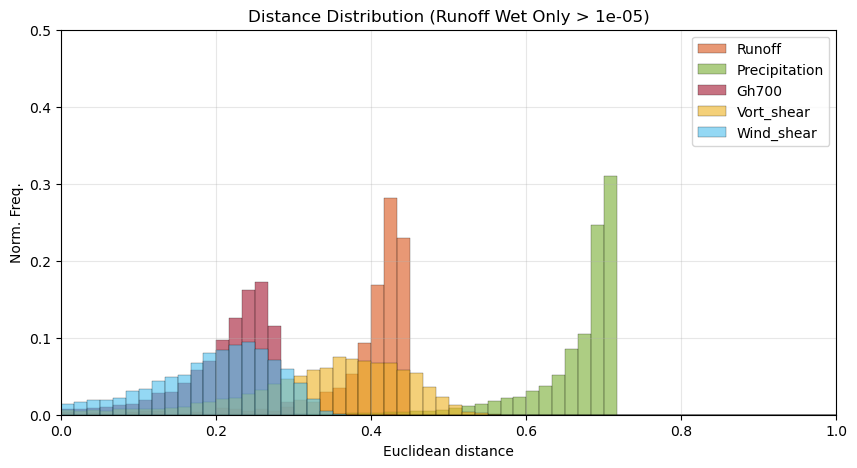


--- Univariate Analysis: runoff ---


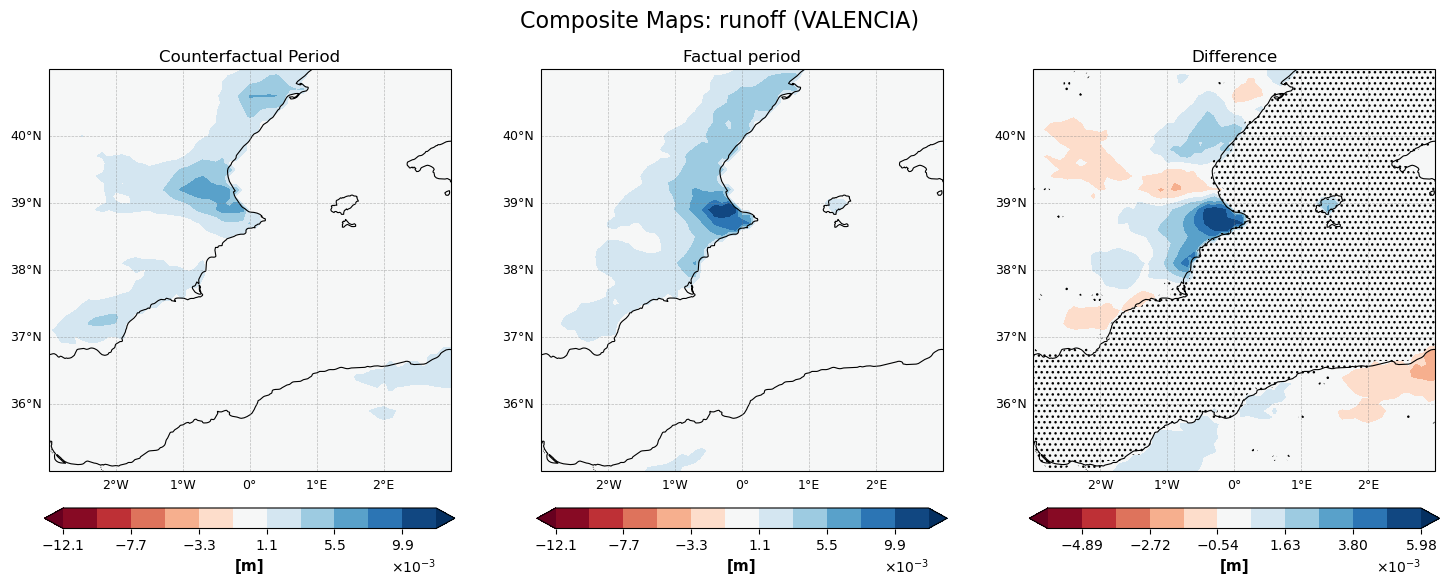

   -> [TREND analysis] Map Generation by Trend Sign...
      Counts -> Pos: 1081, Neu: 5237, Neg: 416


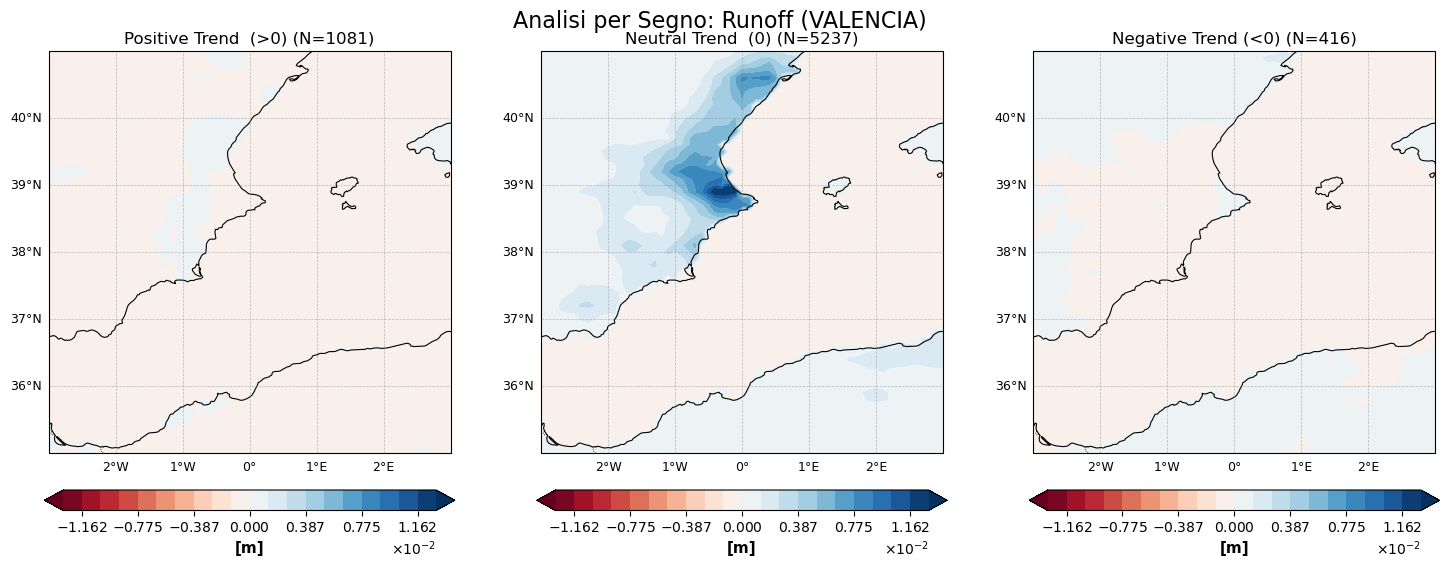


****** [VALENCIA] RUNOFF plot ******


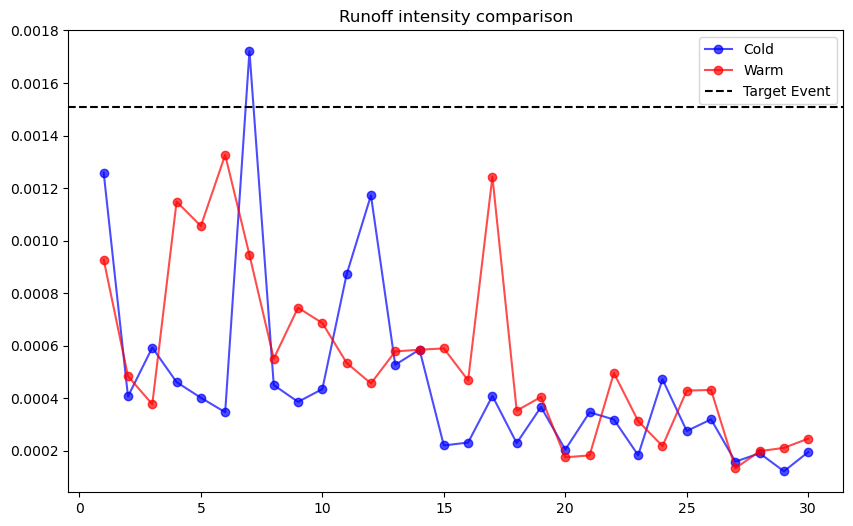


--- Univariate Analysis: precipitation ---


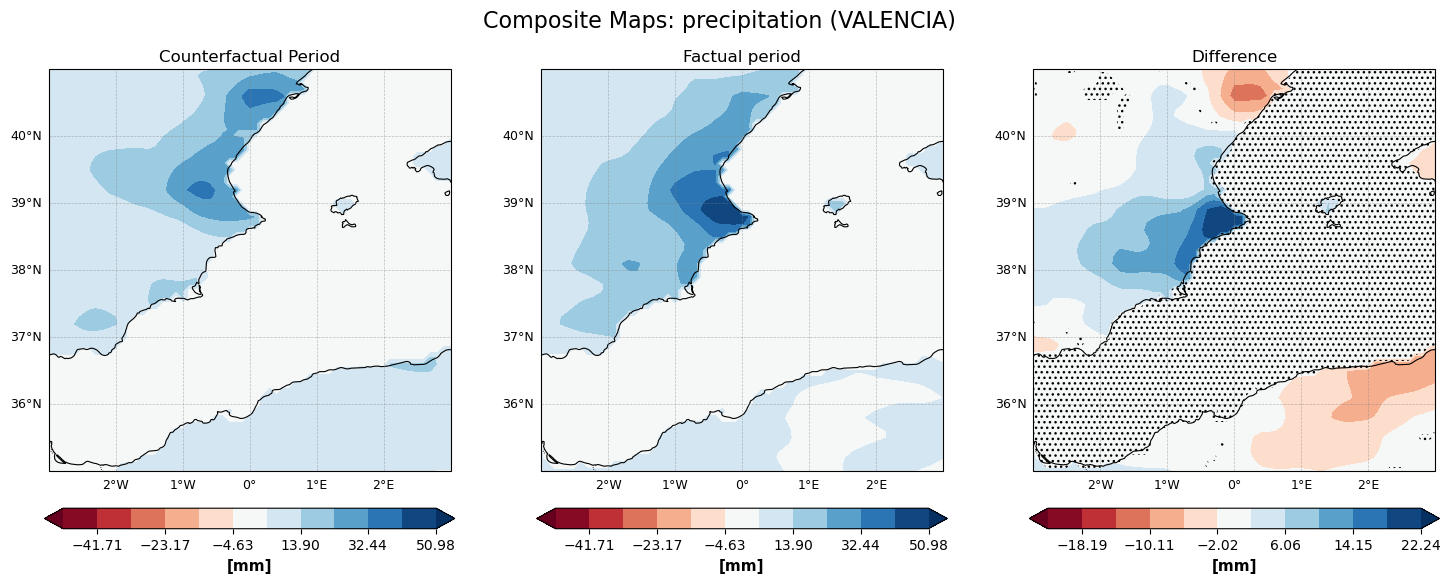

   -> [TREND analysis] Map Generation by Trend Sign...
      Counts -> Pos: 277, Neu: 6198, Neg: 259


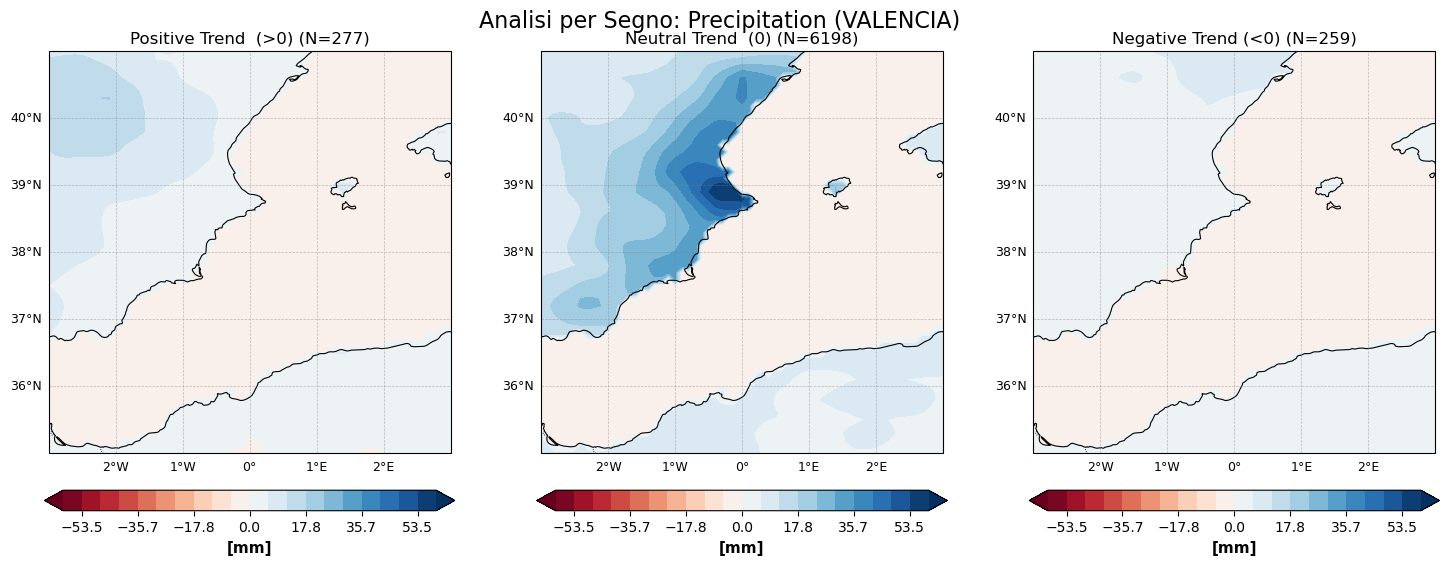


--- Univariate Analysis: gh700 ---


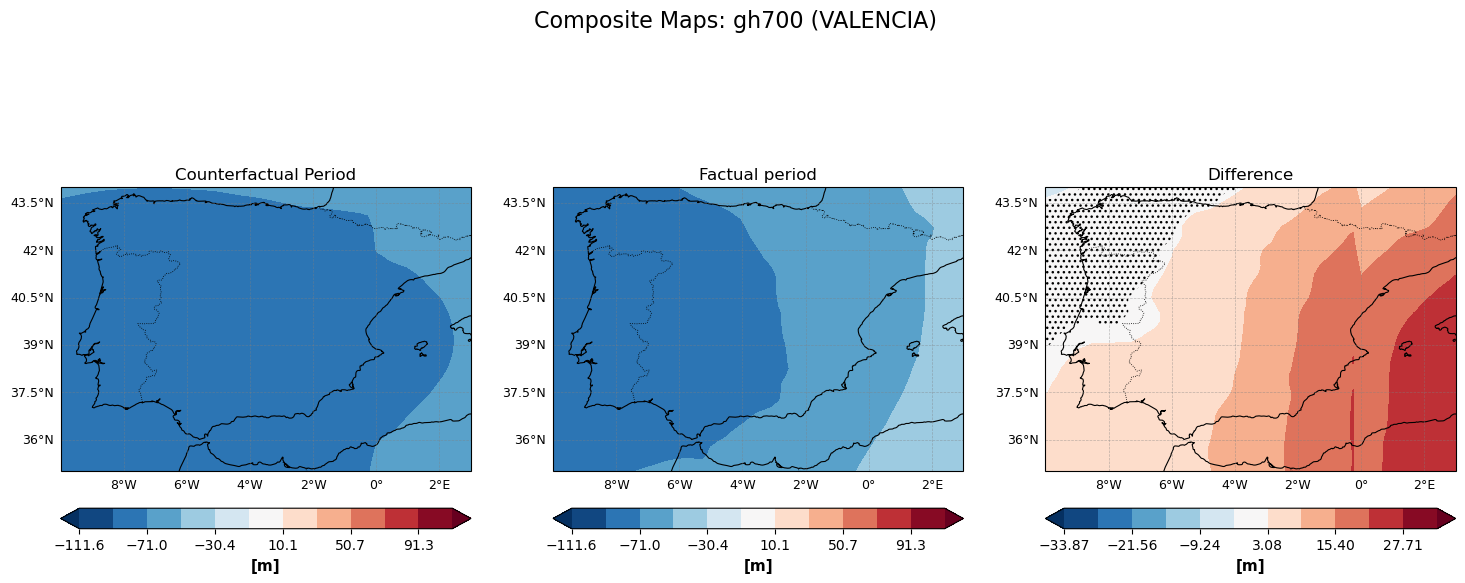

   -> [TREND analysis] Map Generation by Trend Sign...
      Counts -> Pos: 192, Neu: 5766, Neg: 776


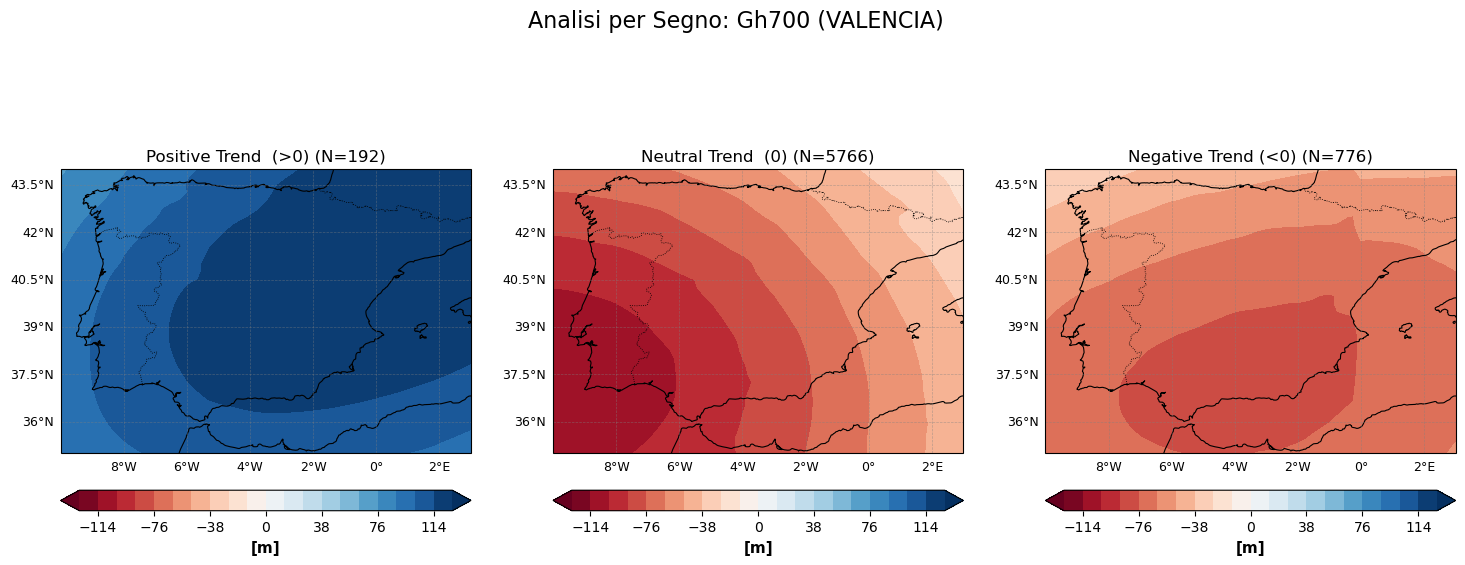


--- Univariate Analysis: vort_shear ---


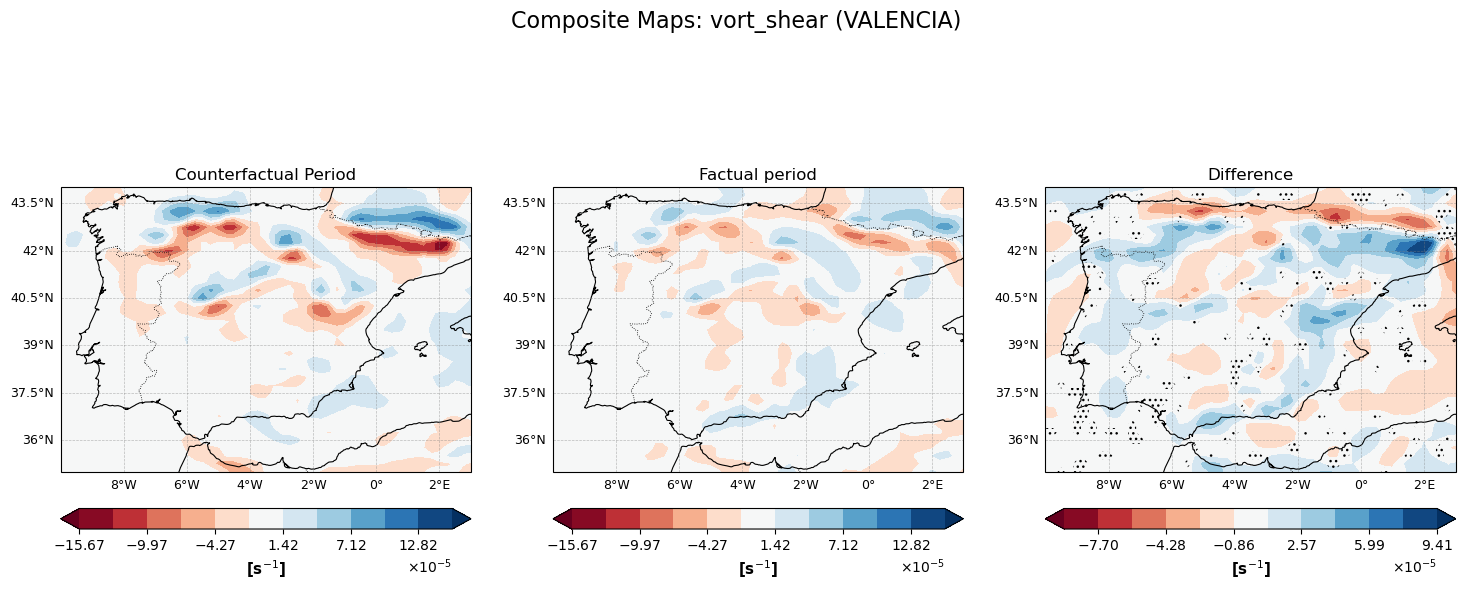

   -> [TREND analysis] Map Generation by Trend Sign...
      Counts -> Pos: 15, Neu: 4066, Neg: 2653


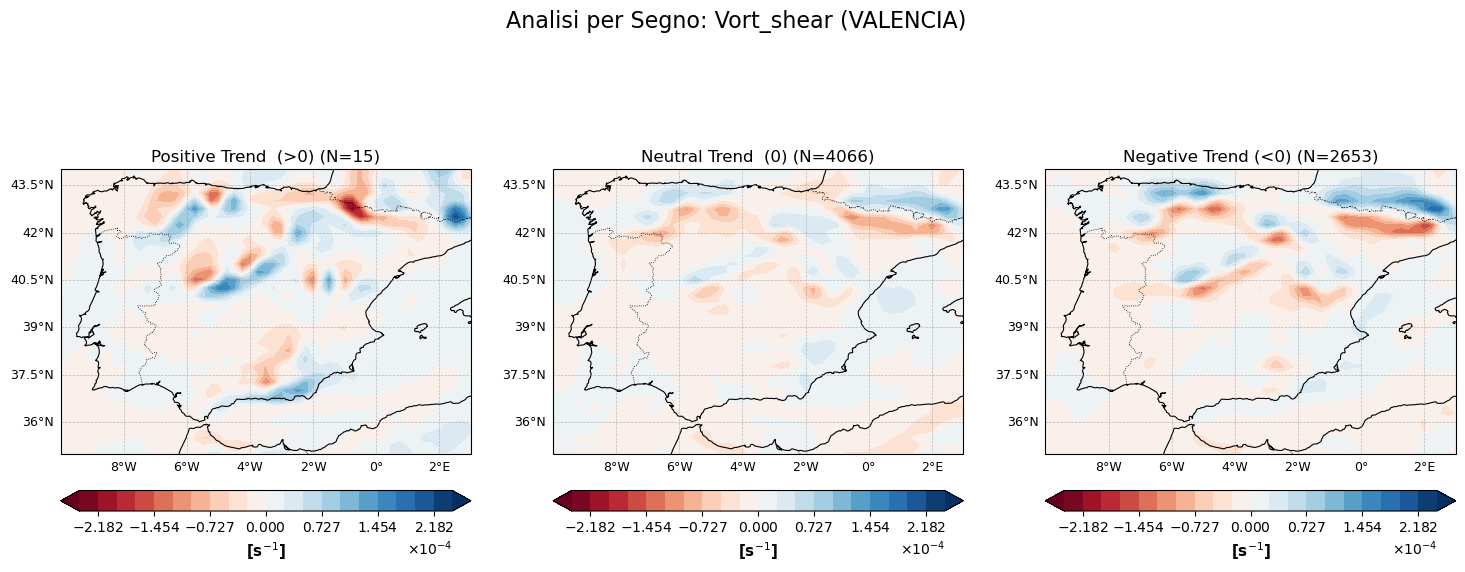


--- Univariate Analysis: wind_shear ---


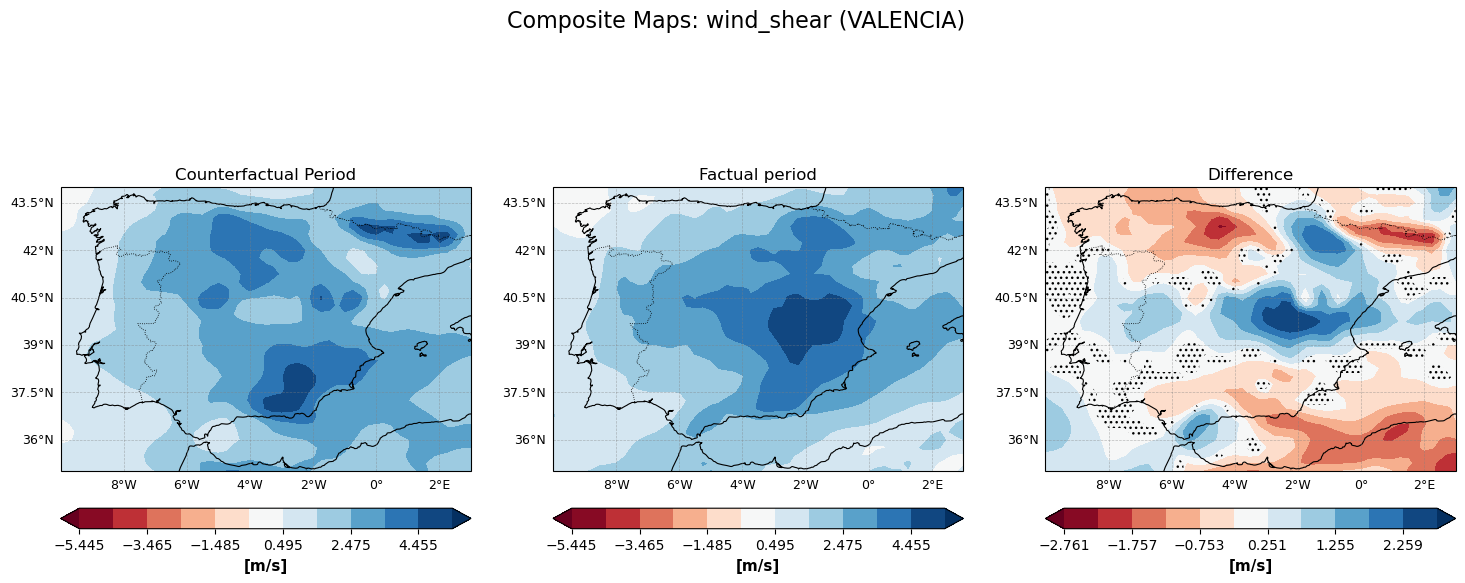

   -> [TREND analysis] Map Generation by Trend Sign...
      Counts -> Pos: 61, Neu: 5206, Neg: 1467


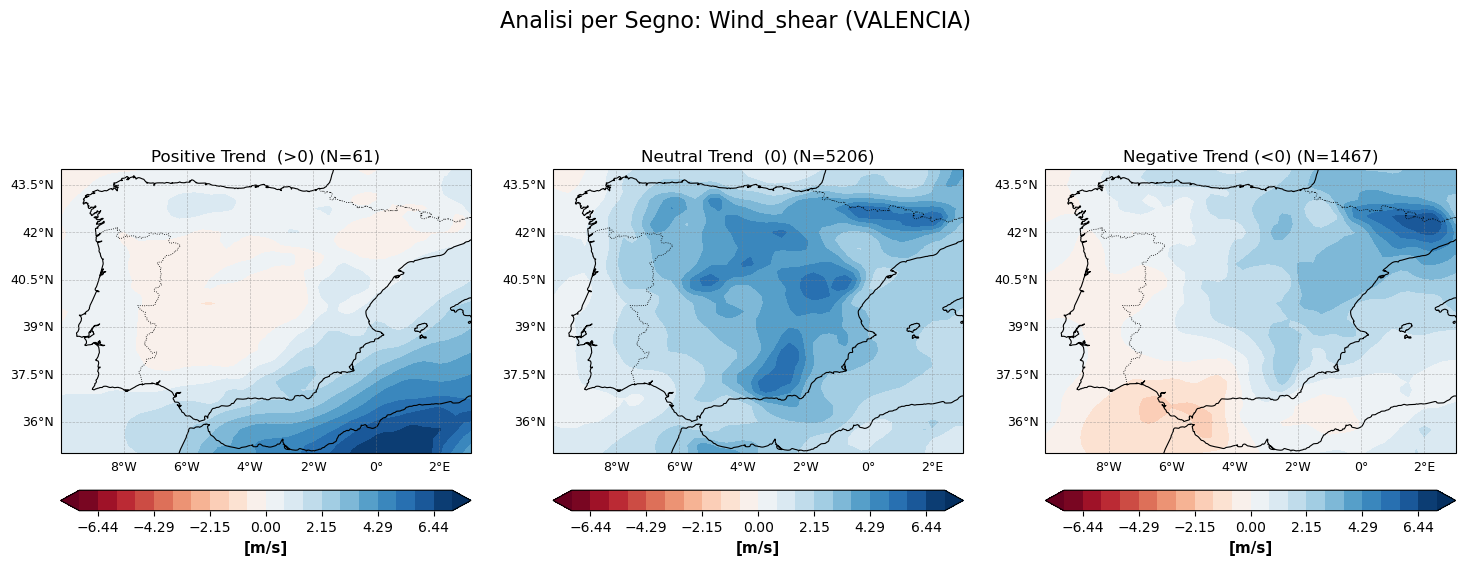


--- Multivariate Analysis: ['precipitation', 'gh700', 'runoff'] ---

========================= TOP 30 ANALOGHI: MULTIVARIATA =========================
Rank  | COUNTERFACTUAL PERIOD | FACTUAL PERIOD      
-------------------------------------------------------
1     | 1982-10-21           | 2019-09-12          
2     | 1966-10-10           | 2012-09-28          
3     | 1971-11-27           | 2012-11-13          
4     | 1969-10-05           | 1988-10-01          
5     | 1984-10-10           | 1996-09-11          
6     | 1973-10-18           | 2015-11-02          
7     | 1953-10-20           | 1987-11-04          
8     | 1959-09-20           | 1989-09-07          
9     | 1957-10-02           | 1994-09-28          
10    | 1962-10-14           | 2019-10-22          
11    | 1961-11-28           | 2018-10-19          
12    | 1962-09-25           | 1993-10-27          
13    | 1971-10-07           | 2023-09-03          
14    | 1984-11-11           | 2000-10-24          
15    | 198

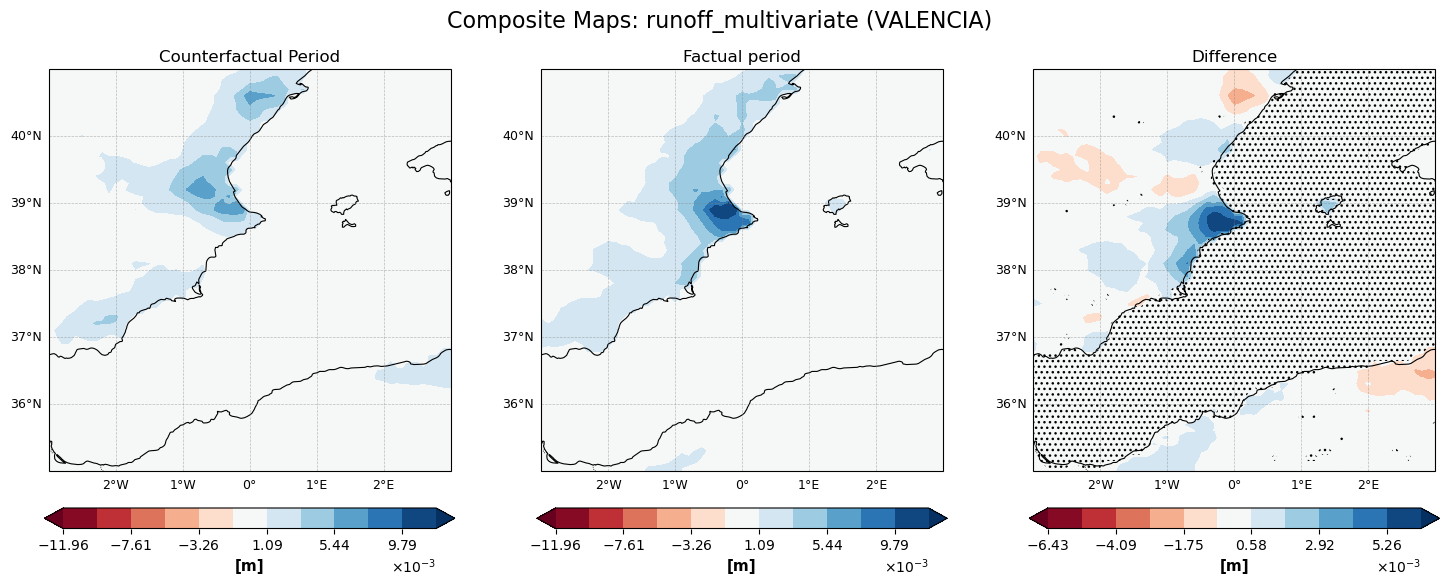

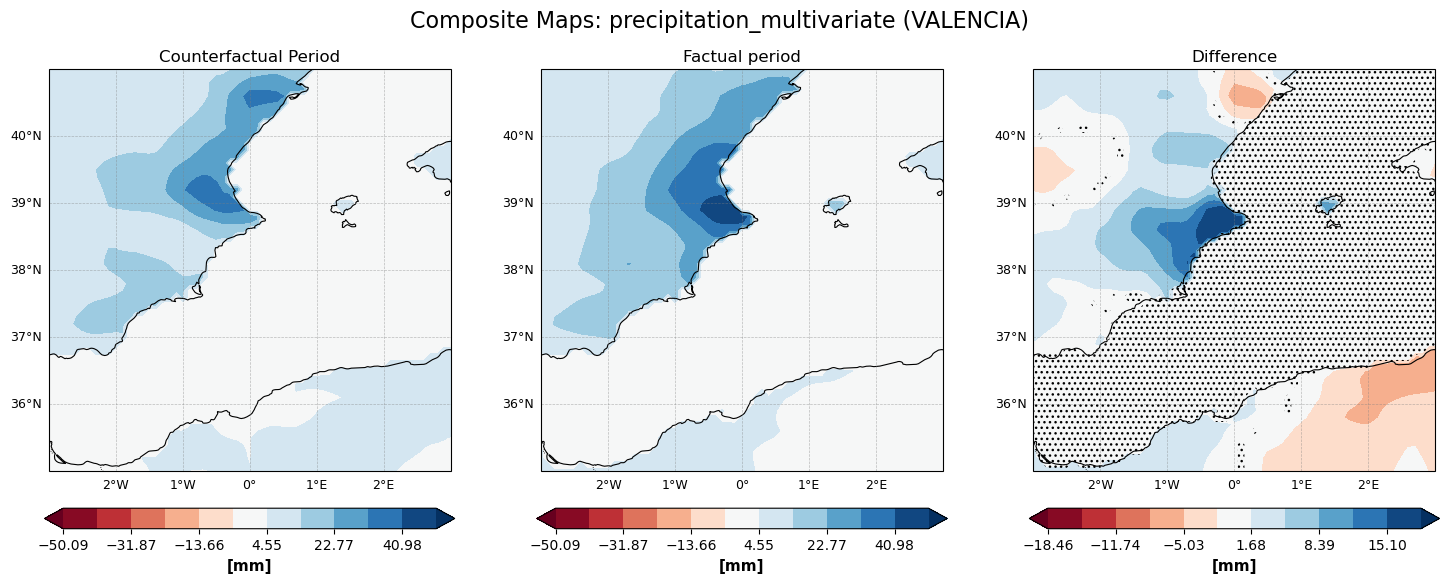

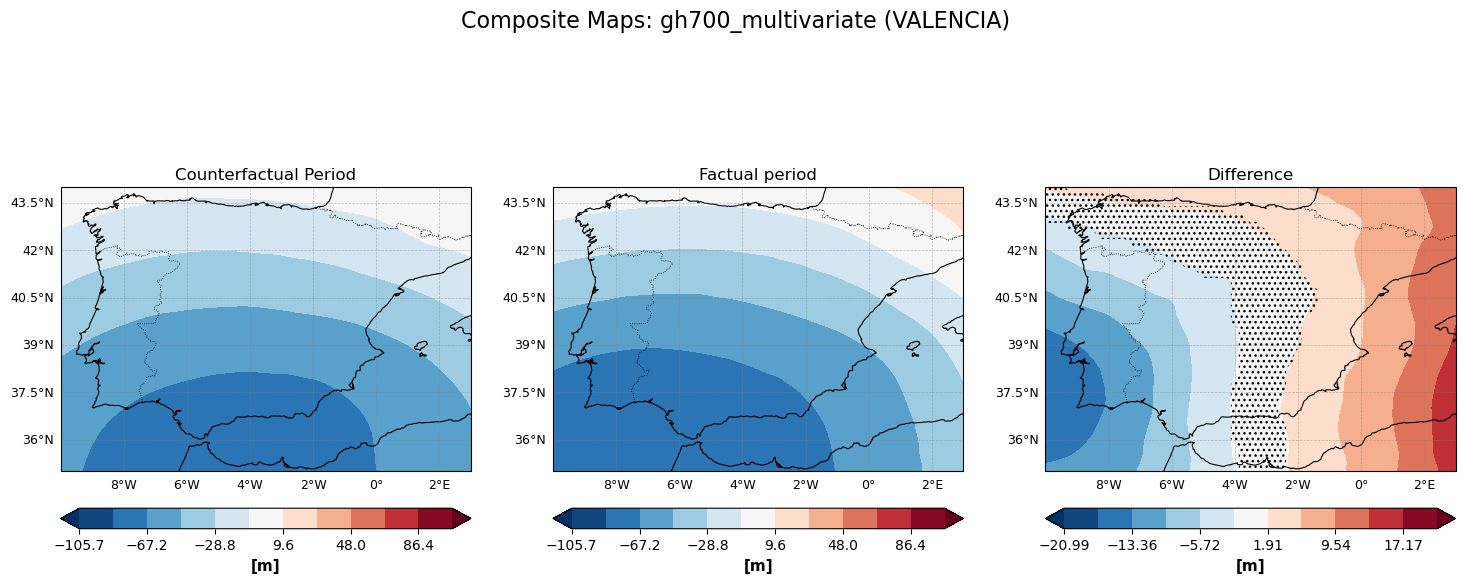

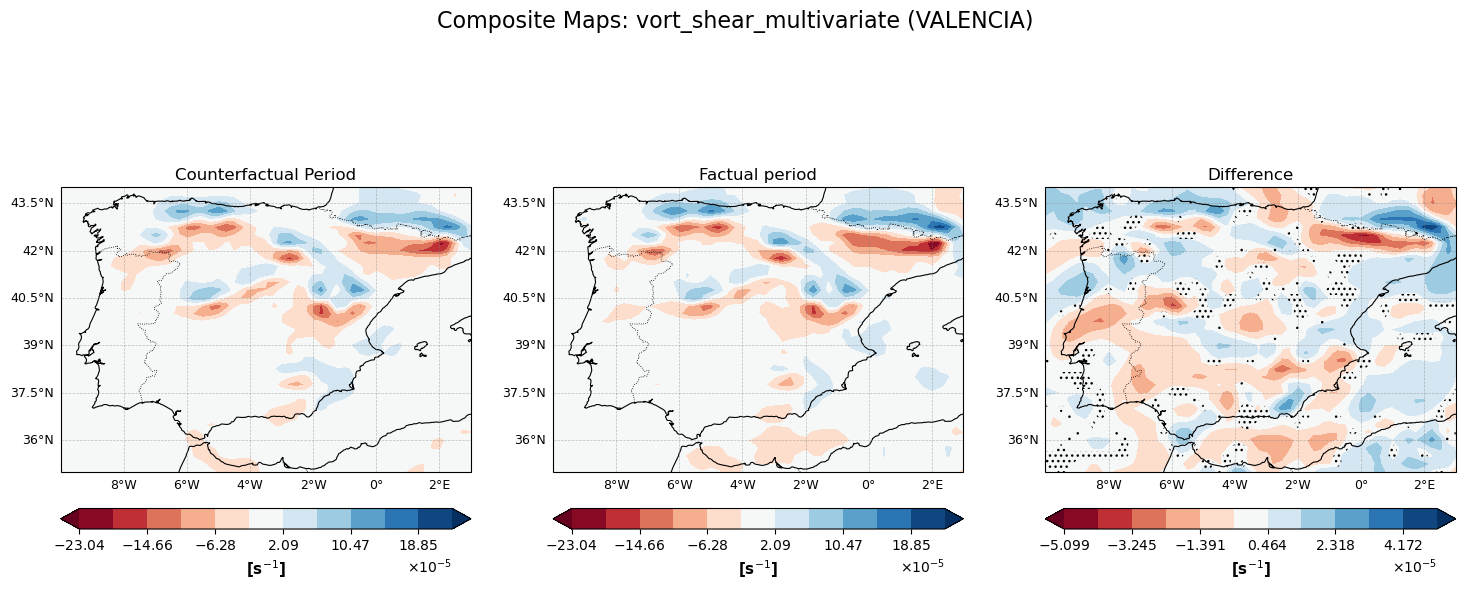

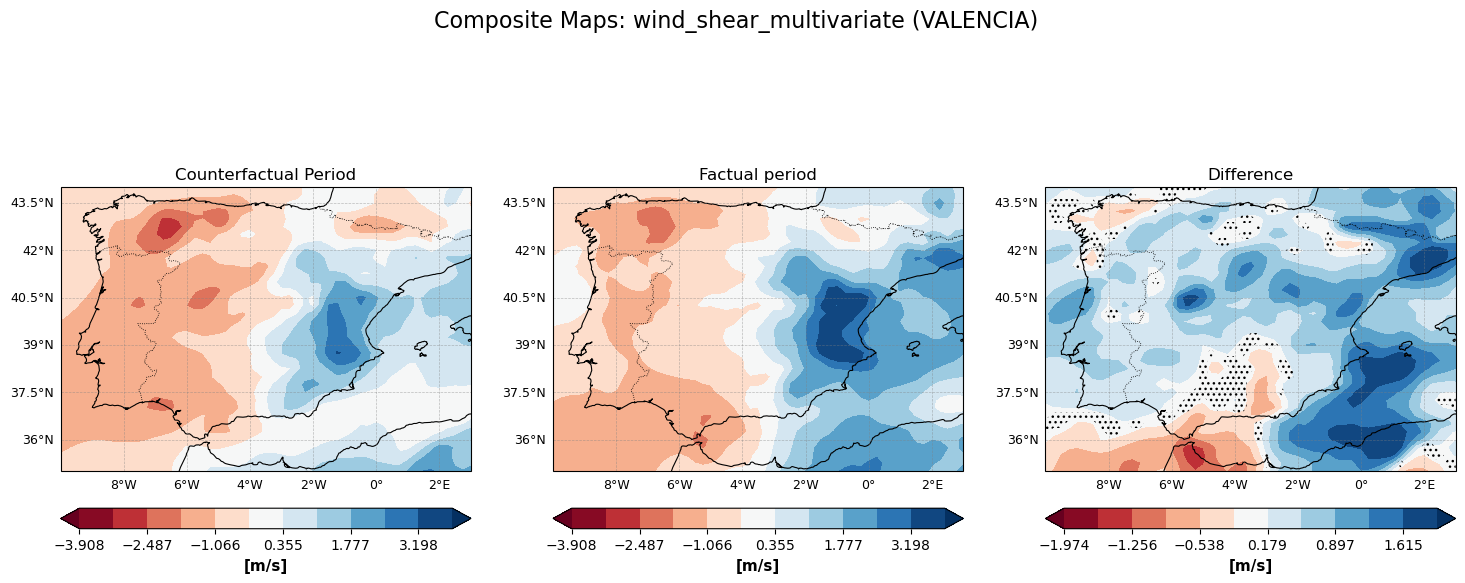


>>> END <<<


In [64]:
def main():
    print(f">>> STARTING ANALYSIS: {CURRENT_CASE} <<<")
    out_dir = Path(config['PATHS']['OUTPUT'])
    fig_dir = out_dir / "FIG"
    fig_dir.mkdir(parents=True, exist_ok=True)

    # 1. PRE-CALCULATION
    if ESEGUI_PRECALCOLO:
        for v in config['VARIABLES']: precompute_variable(v, out_dir)

    if not ESEGUI_ANALISI_PLOT: return

    # 2. LOADING DATA
    data_store = {}
    for v in config['VARIABLES']:
        res = load_precomputed(v['id'], out_dir)
        if res: data_store[v['id']] = res
    if not data_store: print("No data loaded. Check the path and suffixes."); return

    # 3. Temporal filtering and distance calculation
    target_dt = f"{config['DATES']['EVENT_YEAR']}-{config['DATES']['EVENT_DAY']}"
    rel_dists = {}
    print(f"\n>>> Distance Calculation vs {target_dt} (Blacklist: {config['BLACKLIST']})")
    
    for vid, content in data_store.items():
        res, dists = calculate_relative_distances(content['da'], content['dist_av'], target_dt, config['BLACKLIST'])
        if res is not None:
            data_store[vid]['da_filtered'] = res
            rel_dists[vid] = dists

    # 4. HISTOGRAMS
    
    print("\n>>> HISTOGRAM GENERATION <<<")
    hist_vars = {k: rel_dists[k] for k in ['precipitation', 'gh700', 'vort_shear', 'wind_shear', 'runoff'] if k in rel_dists}
    plot_distance_histogram(hist_vars, out_dir, filename="histogram_distances_ALL.png", title=f'Distance Distributions - {target_dt}')

        
    #FOR VALENCIA: histogram with threshold
    if CURRENT_CASE == 'VALENCIA' and 'runoff' in data_store and 'runoff' in rel_dists:
        try:
            ro_da = data_store['runoff']['da_filtered']
            spatial_means = ro_da.mean(dim=['lat', 'lon']).values
            threshold = 0.00001
            is_wet = spatial_means > threshold
            wet_runoff_dists = rel_dists['runoff'][is_wet]
            
            print(f"   Runoff 'Wet' Days (> {threshold}): {len(wet_runoff_dists)} su {len(spatial_means)}")
            
            mixed_dists_store = rel_dists.copy()
            mixed_dists_store['runoff'] = wet_runoff_dists
            
            plot_distance_histogram(mixed_dists_store, out_dir, filename="histogram_distances_WET_RUNOFF.png", title=f'Distance Distribution (Runoff Wet Only > {threshold})')
        except Exception as e:
            print(f"Wet-Runoff histogram generation error: {e}")

 
    # 5. UNIVARIATE ANALYSIS
    for vid in data_store:
        if vid not in rel_dists: continue
        print(f"\n--- Univariate Analysis: {vid} ---")
        analogs = select_analogs(data_store[vid]['da_filtered'], rel_dists[vid], NUM_ANALOGS)
        #print_analog_dates(analogs, vid.upper())
        sig_mask = None
        
        
        if RUN_BOOTSTRAP:
            df = data_store[vid]['da_filtered']
            full_len = len(df)
            dummy_cold_idx = np.arange(full_len // 2)
            dummy_warm_idx = np.arange(full_len - len(dummy_cold_idx))
            current_n_boot = 100
            
            sig_mask = bootstrap_significance(
                None, None, dummy_cold_idx, dummy_warm_idx,
                df[:len(dummy_cold_idx)], df[len(dummy_cold_idx):], 
                analogs['warm']['data'].mean('time') - analogs['cold']['data'].mean('time'), 
                current_n_boot
            )
        
        plot_composite_maps(analogs, vid, fig_dir, sig_mask)

        # Trend Analysis
        if 'signt_da' in data_store[vid]:
            signt_da = data_store[vid]['signt_da']
            signt_aligned = signt_da.sel(time=data_store[vid]['da_filtered'].time).values
            analyze_by_trend_sign(data_store[vid]['da_filtered'], rel_dists[vid], signt_aligned, vid, fig_dir)
            
        # Runoff study for Valencia
        if CURRENT_CASE == 'VALENCIA' and vid == 'runoff':
            analyze_runoff_magnitudes_valencia(analogs, data_store[vid]['da'], target_dt, out_dir)

    # 6. MULTIVARIATE ANALYSIS
    print(f"\n--- Multivariate Analysis: {config['MULTI_VARS']} ---")
    available = [v for v in config['MULTI_VARS'] if v in rel_dists]
    if len(available) == len(config['MULTI_VARS']):
        dist_das = [xr.DataArray(rel_dists[v], coords={'time': data_store[v]['da_filtered'].time}, dims='time') for v in available]
        ds_merged = xr.merge([d.rename(available[i]) for i, d in enumerate(dist_das)], join='inner')
        combined_dist = ds_merged.to_array().sum('variable')
        base_aligned = data_store[available[0]]['da_filtered'].sel(time=combined_dist.time)
        analogs_multi = select_analogs(base_aligned, combined_dist.values, NUM_ANALOGS)
        print_analog_dates(analogs_multi, "MULTIVARIATA")
        
        for tgt in data_store:
            if 'da_filtered' not in data_store[tgt]: continue
            try:
                tgt_da = data_store[tgt]['da_filtered'].sel(time=combined_dist.time)
                mid = len(tgt_da)//2
                an_tgt = {'cold': {'data': tgt_da[:mid].isel(time=analogs_multi['cold']['indices'])},
                          'warm': {'data': tgt_da[mid:].isel(time=analogs_multi['warm']['indices'])}}
                
                
                sig_mask_multi = None
                if RUN_BOOTSTRAP:
                    full_len_m = len(tgt_da)
                    dummy_cold_idx_m = np.arange(full_len_m // 2)
                    dummy_warm_idx_m = np.arange(full_len_m - len(dummy_cold_idx_m))
                    current_n_boot = 100
                    
                    sig_mask_multi = bootstrap_significance(
                        None, None, dummy_cold_idx_m, dummy_warm_idx_m,
                        tgt_da[:len(dummy_cold_idx_m)], tgt_da[len(dummy_cold_idx_m):], 
                        an_tgt['warm']['data'].mean('time') - an_tgt['cold']['data'].mean('time'), 
                        current_n_boot
                    )
                
                plot_composite_maps(an_tgt, f"{tgt}_multivariate", fig_dir, sig_mask_multi)
            except: pass

    # 7. PROXY ANALYSIS(with BOOTSTRAP)
    if ESEGUI_ANALISI_PROXY:
        print("\n--- Proxy Analysi ---")
        for pxy in config['PROXY_VARS']:
            if pxy not in rel_dists: continue
            print(f"Driver: {pxy}")
            d_pxy = xr.DataArray(rel_dists[pxy], coords={'time': data_store[pxy]['da_filtered'].time}, dims='time')
            
            for tgt in data_store:
                if tgt == pxy or 'da_filtered' not in data_store[tgt]: continue
                try:
                    d_aligned = d_pxy.reindex(time=data_store[tgt]['da_filtered'].time, method='nearest', tolerance='1D')
                    valid = ~np.isnan(d_aligned.values)
                    
                    if np.sum(valid) > NUM_ANALOGS*2:
                        tgt_da_proxy = data_store[tgt]['da_filtered'].isel(time=valid)
                        an_pxy = select_analogs(tgt_da_proxy, d_aligned.values[valid], NUM_ANALOGS)
                        
                        
                        sig_mask_proxy = None
                        if RUN_BOOTSTRAP:
                            full_len_p = len(tgt_da_proxy)
                            dummy_cold_idx_p = np.arange(full_len_p // 2)
                            dummy_warm_idx_p = np.arange(full_len_p - len(dummy_cold_idx_p))
                            current_n_boot = 100
                            
                            sig_mask_proxy = bootstrap_significance(
                                None, None, dummy_cold_idx_p, dummy_warm_idx_p,
                                tgt_da_proxy[:len(dummy_cold_idx_p)], tgt_da_proxy[len(dummy_cold_idx_p):], 
                                an_pxy['warm']['data'].mean('time') - an_pxy['cold']['data'].mean('time'), 
                                current_n_boot
                            )
                        
                        plot_composite_maps(an_pxy, f"{tgt}_proxy_{pxy}", fig_dir, sig_mask_proxy)
                except: pass

    print("\n>>> END <<<")

# Esecution
if __name__ == "__main__":
    main()